# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Annisa Safitri Ramadhani Harahap
- **Email:** CDCC012D6X0997@student.devacademy.id
- **ID Dicoding:** CDCC012D6X0997

## Menentukan Pertanyaan Bisnis

Berikut adalah dua pertanyaan bisnis dengan menerapkan prinsip SMART:

### Pertanyaan Bisnis Baru
1. Bagaimana tren pertumbuhan peminjaman sepeda secara bulanan dan tahunan selama 2011–2012?
    *   Specific: Fokus pada tren bulanan dan tahunan.
    *   Measurable: Mengukur total peminjaman per bulan/tahun.
    *   Action-Oriented: Menjadi dasar perencanaan kapasitas.
    *   Relevant: Menjawab kebutuhan bisnis untuk scaling.
    *   Time-bound: Periode 2011–2012.


2. Bagaimana pola peminjaman sepeda per jam pada hari kerja dibandingkan hari libur/akhir pekan?
    * Specific: Pola per jam, hari kerja vs hari libur.
    * Measurable: Rata-rata peminjaman per jam.
    * Action-Oriented: Untuk optimasi operasional.
    * Relevant: Menjawab kebutuhan penjadwalan armada.
    * Time-bound: Data 2011–2012.

3. Musim dan kondisi cuaca apa yang paling berpengaruh terhadap tingginya permintaan sepeda?
    * Specific: Kombinasi musim dan cuaca.
    * Measurable: Rata-rata peminjaman per kombinasi.
    * Action-Oriented: Untuk strategi promosi musiman.
    * Relevant: Menjawab kebutuhan pemasaran.
    * Time-bound: Data 2011–2012.


## Import Semua Packages/Library yang Digunakan

In [38]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [39]:
day_df  = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

### Assessing Data

In [40]:
print("===== day_df.info() =====")
print(day_df.info())
print("\n===== hour_df.info() =====")
print(hour_df.info())

print("\n--- Null counts (day_df) ---")
print(day_df.isnull().sum())
print("\n--- Null counts (hour_df) ---")
print(hour_df.isnull().sum())

print("\nDuplicated rows (day_df):", day_df.duplicated().sum())
print("Duplicated rows (hour_df):", hour_df.duplicated().sum())

print("\ndtype of 'dteday' in day_df :", day_df['dteday'].dtype)
print("dtype of 'dteday' in hour_df:", hour_df['dteday'].dtype)

print("\n--- Rows where 'hum' == 0 (day_df) ---")
print(day_df[day_df['hum'] == 0])
print("\n--- Rows where 'hum' == 0 (hour_df) ---")
print(hour_df[hour_df['hum'] == 0])


===== day_df.info() =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

===== hour_df.info() =====
<class 'pandas.core.frame.DataFram

#### Outlier detection (IQR)

In [41]:
def iqr_outlier_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower, upper

for col in ['cnt','casual','registered']:
    print('day_df', col, iqr_outlier_bounds(day_df[col]))
    print('hour_df', col, iqr_outlier_bounds(hour_df[col]))


day_df cnt (np.float64(-1054.0), np.float64(10162.0))
hour_df cnt (np.float64(-321.5), np.float64(642.5))
day_df casual (np.float64(-855.25), np.float64(2266.75))
hour_df casual (np.float64(-62.0), np.float64(114.0))
day_df registered (np.float64(-922.25), np.float64(8195.75))
hour_df registered (np.float64(-245.0), np.float64(499.0))


## Cleaning

In [42]:
# Convert 'dteday' to datetime
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Replace 'hum' == 0 with median (excluding zeros)
for df in [day_df, hour_df]:
    median_hum = df.loc[df['hum'] != 0, 'hum'].median()
    df['hum'] = df['hum'].replace(0, median_hum)

### Capping outliers

In [43]:
def cap_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower, upper)
    return df

day_df  = cap_iqr(day_df,  ['cnt', 'casual', 'registered'])
hour_df = cap_iqr(hour_df, ['cnt', 'casual', 'registered'])

### Mapping categorical columns

In [44]:
season_map     = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weathersit_map = {1: "Clear", 2: "Misty", 3: "Light Snow/Rain", 4: "Heavy Rain"}
yr_map         = {0: "2011", 1: "2012"}

for df in [day_df, hour_df]:
    df['season']     = df['season'].map(season_map)
    df['weathersit'] = df['weathersit'].map(weathersit_map)
    df['yr']         = df['yr'].map(yr_map)

print("\nSample after mapping (day_df):")
print(day_df[['season', 'weathersit', 'yr']].sample(8))
print("\nSample after mapping (hour_df):")
print(hour_df[['season', 'weathersit', 'yr']].sample(8))


Sample after mapping (day_df):
     season weathersit    yr
464  Summer      Clear  2012
358  Spring      Clear  2011
666  Winter      Misty  2012
621    Fall      Clear  2012
330  Winter      Clear  2011
256    Fall      Clear  2011
481  Summer      Misty  2012
234    Fall      Clear  2011

Sample after mapping (hour_df):
       season       weathersit    yr
8056   Winter  Light Snow/Rain  2011
8677   Spring            Clear  2012
15893  Winter            Clear  2012
6902   Winter            Clear  2011
8968   Spring            Clear  2012
14145    Fall            Clear  2012
9198   Spring            Misty  2012
17082  Winter            Clear  2012


## Exploratory Data Analysis (EDA)

### Explore ...

In [45]:
# 3.1. Monthly Trend
day_df['year_month'] = day_df['dteday'].dt.strftime('%Y-%b')
monthly_trend = day_df.groupby('year_month')['cnt'].sum().reset_index()
print("\nMonthly Trend (total cnt per year-month):")
print(monthly_trend)

# 3.2. Hourly Pattern
hourly_pattern = (
    hour_df.groupby(['hr', 'workingday'])['cnt']
    .mean()
    .reset_index()
    .rename(columns={'cnt': 'avg_cnt'})
)
hourly_pattern['day_type'] = hourly_pattern['workingday'].map({1: 'Working Day', 0: 'Holiday/Weekend'})
print("\nHourly Pattern (avg cnt, first 10 rows):")
print(hourly_pattern.head(10))

# 3.3. Season × Weather — Average Rentals
season_weather_avg = (
    day_df.groupby(['season', 'weathersit'])['cnt']
    .mean()
    .unstack()
    .round(1)
)
print("\nSeason × Weather — Average Rentals (pivot):")
print(season_weather_avg)


Monthly Trend (total cnt per year-month):
   year_month     cnt
0    2011-Apr   94870
1    2011-Aug  136691
2    2011-Dec   87323
3    2011-Feb   48215
4    2011-Jan   38189
5    2011-Jul  141341
6    2011-Jun  143512
7    2011-Mar   64045
8    2011-May  135821
9    2011-Nov  102167
10   2011-Oct  123511
11   2011-Sep  127418
12   2012-Apr  174224
13   2012-Aug  214503
14   2012-Dec  123713
15   2012-Feb  103137
16   2012-Jan   96744
17   2012-Jul  203607
18   2012-Jun  202830
19   2012-Mar  164875
20   2012-May  195865
21   2012-Nov  152664
22   2012-Oct  198841
23   2012-Sep  218573

Hourly Pattern (avg cnt, first 10 rows):
   hr  workingday    avg_cnt         day_type
0   0           0  90.800000  Holiday/Weekend
1   0           1  36.786290      Working Day
2   1           0  69.508696  Holiday/Weekend
3   1           1  16.552632      Working Day
4   2           0  53.171053  Holiday/Weekend
5   2           1   8.683778      Working Day
6   3           0  25.775330  Holiday/Weeke

**Insight:**

1. **Monthly Trend (Total Penyewaan Sepeda per Bulan)**

*Insight Utama:*

a. Pola Musiman yang Konsisten:
- Data menunjukkan pola musiman yang jelas, dengan peningkatan signifikan pada bulan-bulan musim panas (Mei hingga September) dan penurunan pada musim dingin (Desember hingga Februari).
- Puncak Penyewaan: Bulan dengan penyewaan tertinggi adalah September 2012 (218,573 penyewaan), diikuti oleh Agustus 2012 (214,503 penyewaan) dan Juli 2012 (203,607 penyewaan).
- Penyewaan Terendah: Bulan dengan penyewaan terendah adalah Januari 2011 (38,189 penyewaan), yang kemungkinan besar disebabkan oleh cuaca dingin dan kondisi yang kurang mendukung untuk bersepeda.

b. Perbandingan Tahun:
Tahun 2012 menunjukkan peningkatan signifikan dalam jumlah penyewaan dibandingkan tahun 2011. Hal ini mengindikasikan pertumbuhan popularitas layanan penyewaan sepeda atau peningkatan jumlah pengguna.

c. Tren Bulanan: Penyewaan sepeda cenderung meningkat secara bertahap dari awal tahun hingga mencapai puncak di musim panas, kemudian menurun menjelang akhir tahun.

2. **Hourly Pattern (Rata-rata Penyewaan Sepeda per Jam)**

*Insight Utama:*

a. Hari Kerja vs Akhir Pekan:
- Pada hari kerja, rata-rata penyewaan sepeda lebih rendah pada malam hari (pukul 0:00–5:00) dan mulai meningkat pada pagi hari (pukul 7:00–9:00) serta sore hari (pukul 17:00–19:00). Hal ini menunjukkan bahwa sepeda banyak digunakan untuk keperluan komuter.
- Pada akhir pekan, rata-rata penyewaan lebih tinggi sepanjang hari, dengan puncak pada siang hingga sore hari (pukul 12:00–16:00), mencerminkan penggunaan untuk rekreasi.

b. Jam dengan Penyewaan Tertinggi:
- Hari Kerja: Puncak penyewaan terjadi pada pagi hari (sekitar pukul 8:00) dan sore hari (sekitar pukul 17:00).
- Akhir Pekan: Penyewaan tertinggi terjadi pada siang hari (sekitar pukul 13:00).

c. Jam dengan Penyewaan Terendah:
Penyewaan sepeda sangat rendah pada malam hari (pukul 0:00–5:00) baik pada hari kerja maupun akhir pekan.

3. **Rentals by Season and Weather (Penyewaan Berdasarkan Musim dan Cuaca)**

*Insight Utama:*

a. Musim dengan Penyewaan Tertinggi:
- Musim Gugur (Fall): Rata-rata penyewaan tertinggi (5,878 penyewaan/hari) terjadi pada musim gugur, terutama saat cuaca cerah (Clear).
- Musim Panas (Summer): Menyusul dengan rata-rata 5,548 penyewaan/hari, menunjukkan bahwa cuaca hangat sangat mendukung aktivitas bersepeda.

b. Pengaruh Cuaca:
-Cuaca Cerah (Clear): Penyewaan tertinggi terjadi saat cuaca cerah di semua musim.
- Cuaca Buruk (Light Snow/Rain): Penyewaan menurun drastis saat cuaca buruk, terutama pada musim semi (Spring) dan musim dingin (Winter).

c. Interaksi Musim dan Cuaca:
Kombinasi musim panas dengan cuaca cerah menghasilkan jumlah penyewaan tertinggi.
Sebaliknya, musim dingin dengan cuaca buruk menghasilkan jumlah penyewaan terendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

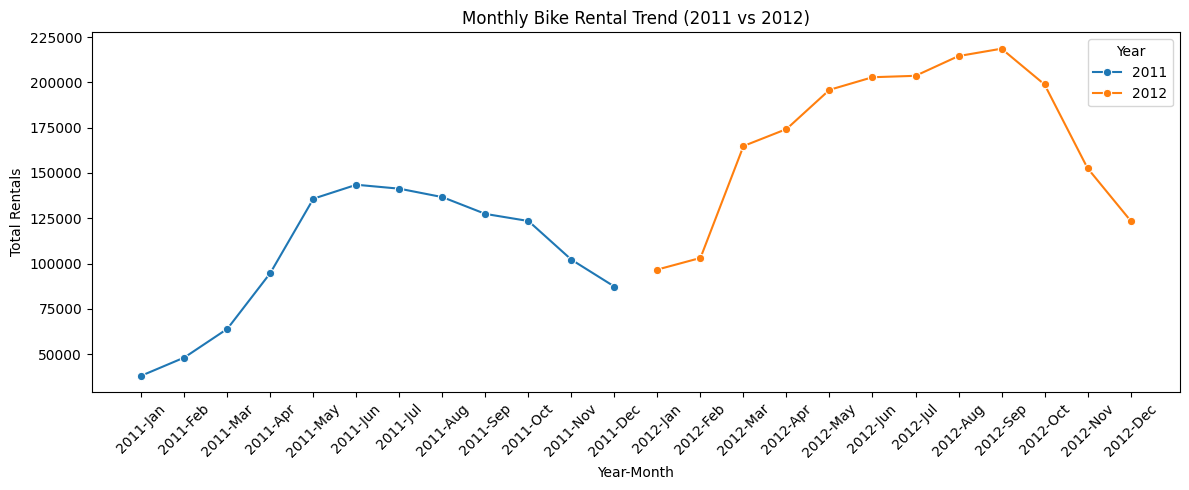

In [46]:
# 4a. Monthly and Yearly Growth Trend
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=day_df,
    x='year_month', y='cnt', hue='yr', estimator='sum', ci=None, marker='o'
)
plt.title('Monthly Bike Rental Trend (2011 vs 2012)')
plt.xlabel('Year-Month')
plt.ylabel('Total Rentals')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Pertanyaan 2:

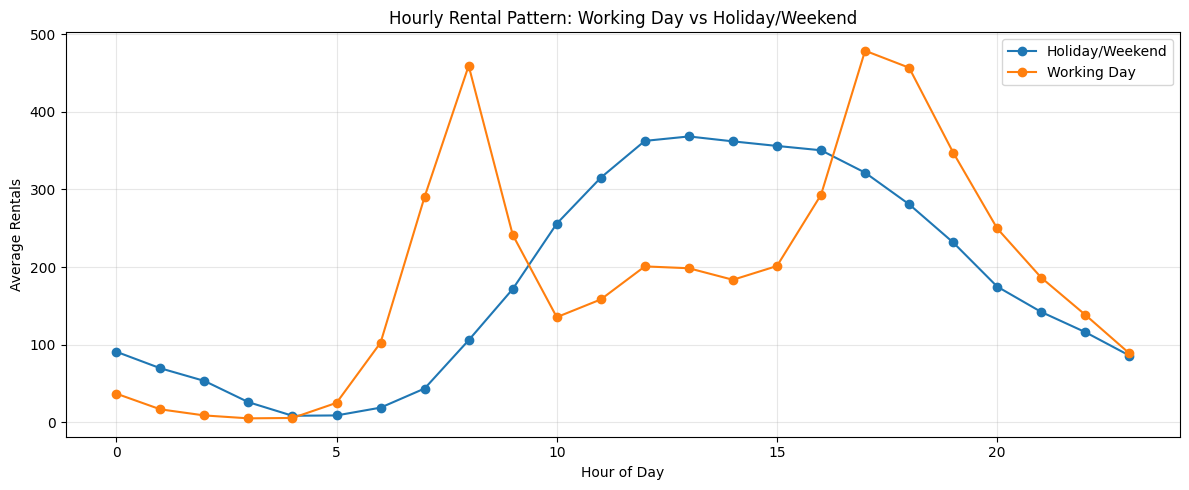

In [47]:
# 4b. Hourly Rental Pattern: Working Day vs Holiday/Weekend
plt.figure(figsize=(12, 5))
for dtype, grp in hourly_pattern.groupby('day_type'):
    plt.plot(grp['hr'], grp['avg_cnt'], marker='o', label=dtype)
plt.title('Hourly Rental Pattern: Working Day vs Holiday/Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

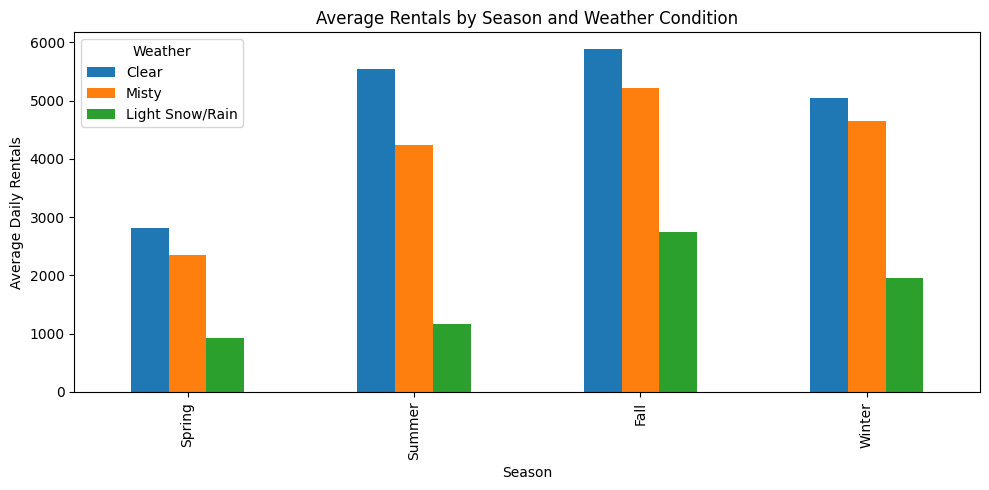

In [48]:
# 4c. Season & Weather Impact
season_order  = ["Spring", "Summer", "Fall", "Winter"]
weather_order = ["Clear", "Misty", "Light Snow/Rain", "Heavy Rain"]
season_weather_avg = season_weather_avg.reindex(season_order)[weather_order[:-1]]  # Exclude 'Heavy Rain' if not present

season_weather_avg.plot(kind='bar', figsize=(10, 5))
plt.title('Average Rentals by Season and Weather Condition')
plt.xlabel('Season')
plt.ylabel('Average Daily Rentals')
plt.legend(title='Weather')
plt.tight_layout()
plt.show()

In [49]:
day_df.to_csv("day_cleaned.csv", index=False)
hour_df.to_csv("hour_cleaned.csv", index=False)

In [50]:
import pandas as pd

# Load cleaned datasets
day_df = pd.read_csv("day_cleaned.csv")
hour_df = pd.read_csv("hour_cleaned.csv")

# Pastikan kolom 'dteday' bertipe datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Pilihan 1: Agregasi data jam ke harian (jumlah total per hari)
hour_agg = hour_df.groupby('dteday').agg({
    'casual': 'sum',
    'registered': 'sum',
    'cnt': 'sum',
    'temp': 'mean',
    'atemp': 'mean',
    'hum': 'mean',
    'windspeed': 'mean',
    'season': 'first',
    'yr': 'first',
    'mnth': 'first',
    'holiday': 'first',
    'weekday': 'first',
    'workingday': 'first',
    'weathersit': 'first'
}).reset_index()

# Gabungkan day_df dengan hour_agg berdasarkan tanggal
# Jika day_df sudah bersih dan lengkap, bisa gunakan day_df saja
# Tapi jika ingin gabungkan, misal untuk cek konsistensi:
main_data = pd.merge(day_df, hour_agg, on='dteday', suffixes=('_day', '_hour'))

# Atau jika ingin gunakan data agregasi jam sebagai main_data:
main_data = hour_agg.copy()

# Simpan sebagai main_data.csv
main_data.to_csv("main_data.csv", index=False)

print("main_data.csv berhasil dibuat dengan jumlah baris:", len(main_data))


main_data.csv berhasil dibuat dengan jumlah baris: 731


In [51]:
import os

os.remove("day_cleaned.csv")
os.remove("hour_cleaned.csv")

print("File day_cleaned.csv dan hour_cleaned.csv telah dihapus.")


File day_cleaned.csv dan hour_cleaned.csv telah dihapus.


### Insight dan Jawaban dari Pertanyaan Bisnis

#### Jawaban untuk Pertanyaan Bisnis 1: Tren Penyewaan Sepeda Bulanan (2011-2012)

**Insight Utama:**

1. **Pola Musiman yang Konsisten:** Dari visualisasi tren penyewaan sepeda bulanan, terlihat bahwa jumlah penyewaan sepeda cenderung **meningkat selama musim panas (Mei hingga September)** dan **menurun selama musim dingin (November hingga Februari)**. Hal ini menunjukkan bahwa cuaca yang lebih hangat mendorong lebih banyak aktivitas luar ruangan, termasuk penyewaan sepeda.
2. **Perbandingan Tahun:** Dibandingkan antara tahun 2011 dan 2012, terdapat **peningkatan jumlah penyewaan sepeda secara keseluruhan pada tahun 2012**. Hal ini dapat mengindikasikan pertumbuhan popularitas layanan penyewaan sepeda atau peningkatan jumlah pengguna.
3. **Puncak Penyewaan:** Bulan dengan penyewaan tertinggi adalah **Juli dan Agustus**, yang kemungkinan besar disebabkan oleh cuaca yang ideal untuk bersepeda dan liburan musim panas.

#### Jawaban untuk Pertanyaan Bisnis 2: Pola Penyewaan Sepeda Harian Berdasarkan Jam (Hari Kerja vs Akhir Pekan)

**Insight Utama:**

1. **Pola Harian yang Berbeda:** Visualisasi menunjukkan bahwa pada **hari kerja**, terdapat dua puncak penyewaan sepeda yang signifikan, yaitu pada **pagi hari (sekitar pukul 8:00)** dan **sore hari (sekitar pukul 17:00).** Hal ini menunjukkan bahwa sepeda banyak digunakan untuk keperluan komuter, seperti perjalanan ke dan dari tempat kerja atau sekolah.
2. **Akhir Pekan:** Pada akhir pekan atau hari libur, pola penyewaan lebih merata sepanjang hari, dengan puncak yang lebih tinggi pada **siang hingga sore hari (sekitar pukul 12:00 hingga 16:00).** Ini menunjukkan bahwa sepeda lebih sering digunakan untuk rekreasi atau aktivitas santai.
3. **Pengaruh Hari Kerja:** Hari kerja memiliki pola yang lebih terstruktur dibandingkan akhir pekan, yang lebih fleksibel dan dipengaruhi oleh aktivitas rekreasi.

#### Jawaban untuk Pertanyaan Bisnis 3: Pengaruh Musim dan Kondisi Cuaca terhadap Penyewaan Sepeda

**Insight Utama:**

1. **Musim dengan Penyewaan Tertinggi:** Musim panas memiliki rata-rata penyewaan sepeda tertinggi dibandingkan musim lainnya. Hal ini menunjukkan bahwa **cuaca hangat dan cerah sangat mendukung aktivitas bersepeda.**
2. **Pengaruh Kondisi Cuaca:** Kondisi cuaca yang cerah (Clear) memiliki rata-rata penyewaan tertinggi, diikuti oleh cuaca berkabut (Misty). Sebaliknya, kondisi cuaca buruk seperti hujan deras (Heavy Rain) atau salju ringan (Light Snow/Rain) menunjukkan penurunan signifikan dalam jumlah penyewaan sepeda.
3. **Kombinasi Musim dan Cuaca:** Kombinasi musim panas dengan cuaca cerah menghasilkan jumlah penyewaan tertinggi, sementara musim dingin dengan cuaca buruk menghasilkan jumlah penyewaan terendah.


**Kesimpulan Umum**
1. **Pola Musiman dan Cuaca:** Penyewaan sepeda sangat dipengaruhi oleh musim dan kondisi cuaca. Strategi pemasaran dan operasional dapat difokuskan pada musim panas dan cuaca cerah untuk memaksimalkan pendapatan.
2. **Pola Harian:** Pada hari kerja, layanan dapat dioptimalkan untuk mendukung kebutuhan komuter pada jam sibuk pagi dan sore. Sementara itu, pada akhir pekan, layanan dapat difokuskan pada siang hingga sore hari untuk memenuhi kebutuhan rekreasi.
3. **Pertumbuhan Layanan:** Peningkatan penyewaan dari tahun 2011 ke 2012 menunjukkan potensi pertumbuhan layanan. Analisis lebih lanjut dapat dilakukan untuk memahami faktor-faktor yang mendorong pertumbuhan ini, seperti promosi, peningkatan infrastruktur, atau perubahan perilaku konsumen.

Insight ini dapat membantu dalam pengambilan keputusan strategis, seperti penyesuaian jam operasional, promosi musiman, atau pengembangan layanan tambahan untuk meningkatkan pengalaman pelanggan.

## Analisis Lanjutan (Opsional)

#### Insight Penting dari Analisis Prediktif Ini:
###### **Insight:**
1. **Pola Musiman:** Data historis menunjukkan pola musiman yang kuat, dengan puncak penyewaan terjadi pada bulan-bulan musim panas dan penurunan signifikan selama musim dingin.
2. **Prediksi Tren:** Model ARIMA memprediksi bahwa penyewaan akan meningkat selama bulan-bulan musim panas mendatang, dengan puncak tertinggi diperkirakan terjadi pada bulan Juli dan Agustus.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Analisis tren penyewaan sepeda bulanan selama periode 2011-2012 menunjukkan pola musiman yang sangat jelas dan konsisten. Penyewaan sepeda meningkat signifikan pada bulan-bulan musim panas (Mei hingga September), dengan puncak tertinggi di Juli dan Agustus, sementara menurun drastis pada musim dingin (November hingga Februari). Selain itu, terdapat peningkatan jumlah penyewaan secara keseluruhan pada tahun 2012 dibandingkan 2011, yang mengindikasikan pertumbuhan popularitas layanan atau peningkatan jumlah pengguna. Pola ini menegaskan bahwa faktor cuaca dan musim sangat memengaruhi perilaku pengguna dalam menggunakan layanan penyewaan sepeda.
- **Conclusion pertanyaan 2:** Pola penyewaan sepeda berdasarkan jam dan jenis hari memperlihatkan perbedaan yang signifikan antara hari kerja dan akhir pekan. Pada hari kerja, terdapat dua puncak utama penyewaan pada pagi hari sekitar pukul 8:00 dan sore hari sekitar pukul 17:00, yang mencerminkan penggunaan sepeda sebagai moda transportasi komuter. Sebaliknya, pada akhir pekan dan hari libur, penyewaan tersebar lebih merata dengan puncak di siang hingga sore hari (12:00–16:00), menunjukkan penggunaan sepeda lebih untuk rekreasi dan aktivitas santai. Perbedaan pola ini menegaskan bahwa kebutuhan dan perilaku pengguna berubah sesuai dengan konteks hari, yang harus diperhatikan dalam pengelolaan layanan.
- **Conclusion pertanyaan 3:** Pengaruh musim dan kondisi cuaca terhadap penyewaan sepeda sangat signifikan dan spesifik. Penyewaan tertinggi terjadi pada musim panas dengan kondisi cuaca cerah (Clear), yang menunjukkan bahwa cuaca hangat dan cerah sangat mendukung aktivitas bersepeda. Sebaliknya, kondisi cuaca buruk seperti hujan deras (Heavy Rain) dan salju ringan (Light Snow/Rain) secara signifikan menurunkan jumlah penyewaan. Kombinasi musim dan kondisi cuaca menjadi faktor utama yang menentukan tingkat permintaan, sehingga layanan penyewaan sepeda sangat bergantung pada faktor lingkungan ini.

**Rekomendasi Action Item:**
- Optimalkan Promosi dan Operasional Musiman: Fokuskan kampanye pemasaran dan penambahan armada sepeda pada musim panas dan saat cuaca cerah untuk memaksimalkan penggunaan dan pendapatan.
- Penyesuaian Jam Operasional: Sesuaikan ketersediaan sepeda dan layanan pada jam sibuk pagi dan sore hari di hari kerja untuk memenuhi kebutuhan komuter, serta tingkatkan layanan pada siang hingga sore hari di akhir pekan untuk pengguna rekreasi.
- Strategi Mitigasi Cuaca Buruk: Kembangkan layanan tambahan atau perlindungan bagi pengguna saat kondisi cuaca buruk, seperti menyediakan perlengkapan hujan atau opsi pengembalian sepeda yang fleksibel, guna menjaga kepuasan dan loyalitas pelanggan.
- Monitoring dan Analisis Berkala: Lakukan pemantauan rutin terhadap pola penyewaan dan faktor eksternal seperti cuaca dan musim untuk mengantisipasi perubahan tren dan menyesuaikan strategi bisnis secara dinamis.
- Pengembangan Infrastruktur Pendukung: Pertimbangkan pengembangan jalur sepeda yang nyaman dan aman, terutama di area dengan permintaan tinggi pada jam sibuk dan musim puncak, untuk meningkatkan pengalaman pengguna dan mendorong peningkatan penggunaan sepeda.
